# ESRC Micro-Ablation — Final Analysis

Which personal signals matter most for LLM-based deanonymization?

This notebook is a thin reproducible wrapper over the pipeline in `src/`. It does **not** call any API — it loads the
experiment outputs from `experiments/` and the tables/figures from `results/`. To (re)generate them run `./run_study.sh`.


In [1]:
import os, sys, json
import pandas as pd
from IPython.display import Image, display

# locate project root (the folder that contains 'src')
root = os.getcwd()
while not os.path.isdir(os.path.join(root, 'src')) and root != '/':
    root = os.path.dirname(root)
sys.path.insert(0, os.path.join(root, 'src'))
import common as C
TBL = lambda n: C.path(C.RES_TABLES, n)
FIG = lambda n: C.path(C.RES_FIGURES, n)
EXP = lambda n: C.path(C.EXP, n)
print('project root:', root)


project root: /Users/elenasviatko/Desktop/ESRC-Micro-2026


## Experiment 1 — Leave-One-Out + Signal Importance Score (SIS)

`SIS(C) = (recall_full - recall_without_C) / recall_full * 100`. We rank categories by rank-1 SIS; Recall@90% precision is also reported (it is near zero at this sample size).


In [2]:
display(pd.read_csv(TBL('en_leave_one_out.csv')))
display(pd.read_csv(TBL('hn_leave_one_out.csv')))


,condition,recall@90,r90_CI,recall@99,rank1_acc,retrieved@15,SIS_recall90,SIS_rank1,t_pvalue,cohens_d,mcnemar_p
0,FULL,0.0000,"[0.0, 0.013]",0.0000,0.1899,0.430,NaN,NaN,NaN,NaN,NaN
1,NO_GEO,0.0127,"[0.0, 0.038]",0.0127,0.1456,0.405,0.0,23.3,0.1085,0.128,0.1671
2,NO_PROF,0.0063,"[0.0, 0.019]",0.0063,0.2468,0.411,0.0,-30.0,0.0603,-0.151,0.0931
3,NO_DEMO,0.0063,"[0.0, 0.025]",0.0063,0.1962,0.424,0.0,-3.3,0.7641,-0.024,1.0000
4,NO_INT,0.0000,"[0.0, 0.0]",0.0000,0.2342,0.386,0.0,-23.3,0.1946,-0.104,0.2649
5,NO_VAL,0.0063,"[0.0, 0.025]",0.0063,0.1456,0.380,0.0,23.3,0.1085,0.128,0.1671
6,NO_STYLE,0.0127,"[0.0, 0.032]",0.0127,0.1013,0.418,0.0,46.7,0.0004,0.289,0.0005


,condition,recall@90,r90_CI,recall@99,rank1_acc,retrieved@15,SIS_recall90,SIS_rank1,t_pvalue,cohens_d,mcnemar_p
0,FULL,0.0,"[0.0, 0.03]",0.0,0.101,0.404,NaN,NaN,NaN,NaN,NaN
1,NO_GEO,0.0,"[0.0, 0.0]",0.0,0.000,0.313,0.0,100.0,0.0013,0.334,0.002
2,NO_PROF,0.0,"[0.0, 0.0]",0.0,0.000,0.424,0.0,100.0,0.0013,0.334,0.002
3,NO_DEMO,0.0,"[0.0, 0.0]",0.0,0.000,0.394,0.0,100.0,0.0013,0.334,0.002
4,NO_INT,0.0,"[0.0, 0.0]",0.0,0.000,0.374,0.0,100.0,0.0013,0.334,0.002
5,NO_VAL,0.0,"[0.0, 0.0]",0.0,0.000,0.384,0.0,100.0,0.0013,0.334,0.002
6,NO_STYLE,0.0,"[0.0, 0.0]",0.0,0.000,0.404,0.0,100.0,0.0013,0.334,0.002


### SIS — Reddit vs Hacker News


,category,SIS_Reddit,SIS90_Reddit,rank1_Reddit,SIS_HN,SIS90_HN,rank1_HN
0,GEO,23.3,0.0,0.1456,100.0,0.0,0.0
1,PROF,-30.0,0.0,0.2468,100.0,0.0,0.0
2,DEMO,-3.3,0.0,0.1962,100.0,0.0,0.0
3,INT,-23.3,0.0,0.2342,100.0,0.0,0.0
4,VAL,23.3,0.0,0.1456,100.0,0.0,0.0
5,STYLE,46.7,0.0,0.1013,100.0,0.0,0.0


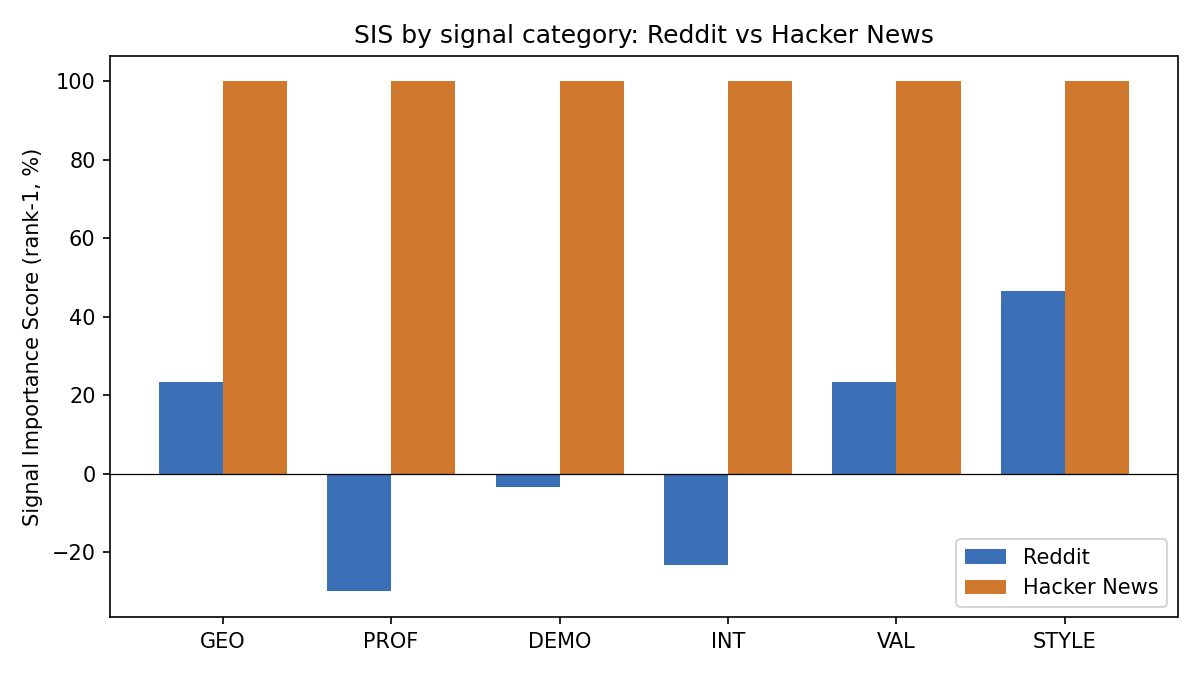

In [3]:
display(pd.read_csv(TBL('sis_reddit_vs_hn.csv')))
display(Image(FIG('sis_reddit_vs_hn.png')))


## Experiment 2 — Additive ablation (Minimum Sufficient Signal Set)

Smallest prefix of categories reaching >=80% of full rank-1 accuracy = **MSSS**.


EN order: GEO+VAL+DEMO+INT+PROF | MSSS = GEO+VAL+DEMO
HN order: GEO+PROF+DEMO+INT+VAL | MSSS = GEO+PROF+DEMO+INT+VAL+STYLE


,step,profile,recall@90,rank1_acc,frac_of_full
0,1,GEO,0.0316,0.1329,0.700
1,2,GEO+VAL,0.0063,0.1329,0.700
2,3,GEO+VAL+DEMO,0.0063,0.1519,0.800
3,4,GEO+VAL+DEMO+INT,0.0063,0.1456,0.767
4,5,GEO+VAL+DEMO+INT+PROF,0.0000,0.1013,0.533
5,6,GEO+VAL+DEMO+INT+PROF+STYLE,0.0000,0.1899,1.000


,step,profile,recall@90,rank1_acc,frac_of_full
0,1,GEO,0.0,0.0,0.0
1,2,GEO+PROF,0.0,0.0,0.0
2,3,GEO+PROF+DEMO,0.0,0.0,0.0
3,4,GEO+PROF+DEMO+INT,0.0,0.0,0.0
4,5,GEO+PROF+DEMO+INT+VAL,0.0,0.0,0.0
5,6,GEO+PROF+DEMO+INT+VAL+STYLE,0.0,0.0,0.0


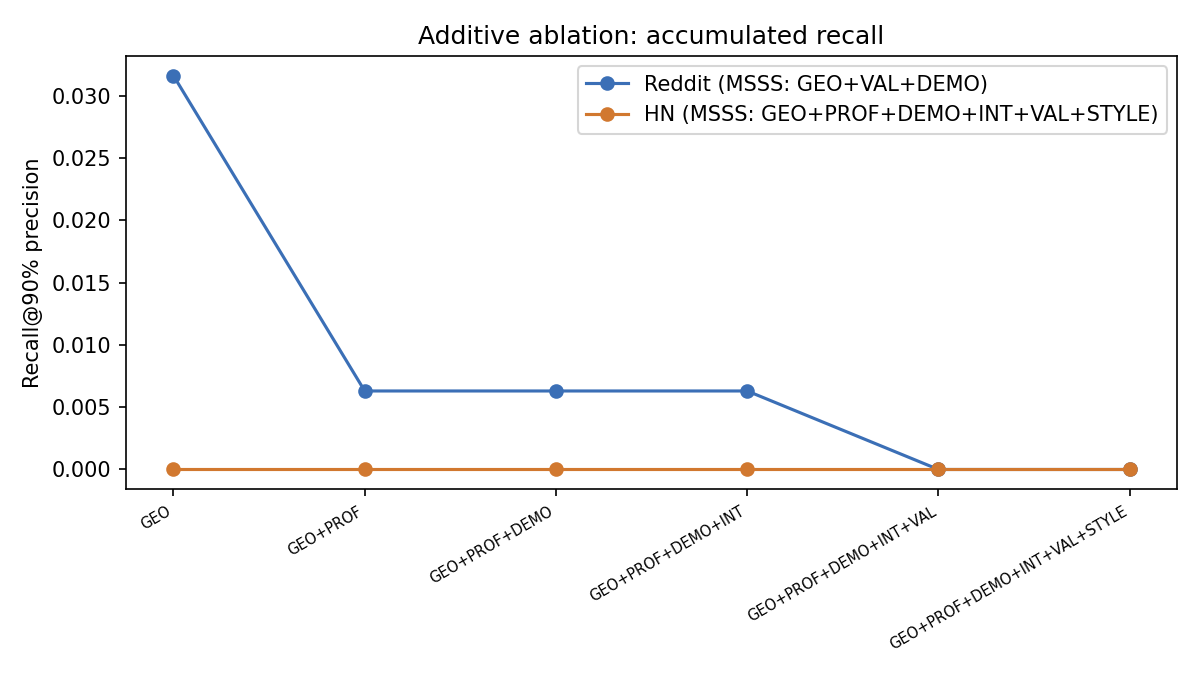

In [4]:
for tag in ['en','hn']:
    d = json.load(open(EXP(f'{tag}_additive.json')))
    print(tag.upper(), 'order:', '+'.join(d['order']), '| MSSS =', d['MSSS'])
display(pd.read_csv(TBL('en_additive.csv')))
display(pd.read_csv(TBL('hn_additive.csv')))
display(Image(FIG('additive_recall_curve.png')))


## Experiment 3 — Interaction (substitutive vs complementary)


In [5]:
display(pd.read_csv(TBL('en_interaction.csv')))


,pair,recall@90_without_both,dI,dJ,dIJ,dI+dJ,interaction
0,DEMO+VAL,0.1203,-0.0127,-0.0253,-0.0127,-0.0380,substitutive
1,DEMO+GEO,0.1203,-0.0127,-0.0380,-0.0127,-0.0507,substitutive
2,VAL+GEO,0.1139,-0.0253,-0.0380,-0.0063,-0.0633,substitutive


## Writing style alone — by TTR group

Can writing style alone identify a user? We test whether a richer vocabulary (higher type-token ratio) makes a user easier to identify.


In [6]:
display(pd.read_csv(TBL('en_style_by_ttr.csv')))


,group,n,ttr_range,recall@90,rank1_acc
0,low_TTR,52,"[0.096, 0.178]",0.0769,0.1731
1,mid_TTR,53,"[0.179, 0.218]",0.0000,0.1132
2,high_TTR,53,"[0.22, 0.362]",0.0000,0.1132


## Qualitative — success / failure breakdown


In [7]:
for tag in ['en','hn']:
    d = json.load(open(EXP(f'{tag}_qualitative.json')))
    print(f"{d['pool']}: success={d['n_success']} failure={d['n_failure']} "
          f"(retrieval-miss={d['failure_due_to_retrieval_miss']}, "
          f"wrong-pick={d['failure_due_to_wrong_reason_pick']})")
# one example success case (Reddit)
ex = json.load(open(EXP('en_qualitative.json')))['success_cases'][0]
print('\nexample success:'); print(json.dumps(ex, indent=2)[:600])


POOL-EN: success=30 failure=128 (retrieval-miss=90, wrong-pick=38)
POOL-HN: success=10 failure=89 (retrieval-miss=59, wrong-pick=30)

example success:
{
  "uid": "user_043ea160",
  "predicted": "user_043ea160",
  "correct": true,
  "confidence": 0.8,
  "retrieved_true": true,
  "query_profile": "lives_in_portland, male, has_wife, open_relationship, interested_in_sexuality, enjoys_photography, technology_mod, writes_fantasy_literature, nerdy, interested_in_kinks, focuses_on_communication, has_experience_with_kegels, enjoys_prostate_stimulation, prefers_gentle_touch, values_honesty_in_relationships, believes_in_continuous_learning. writing style: avg sentence length 11.3 words, avg word length 4.28 chars, type-token ratio 0.143, punctuation 12


---
Leave-One-Out and Additive (Reddit and Hacker News) use gpt-4o; the Interaction and writing-style experiments use the cheaper model. Everything can be regenerated with `./run_study.sh`.
